# Test Data Loading

In [1]:
import cma
import pandas as pd

### Vessel Data

In [2]:
vesselpool = cma.read_vessel_class_data()
vesselpool

       Vessel Type  Vessel Number
0    Rank 1 Vessel             21
1    Rank 2 Vessel             41
2    Rank 3 Vessel             62
3    Rank 4 Vessel             71
4    Rank 5 Vessel             86
5    Rank 6 Vessel             39
6    Rank 7 Vessel             68
7    Rank 8 Vessel             54
8    Rank 9 Vessel             57
9   Rank 10 Vessel             48
10  Rank 11 Vessel             25
11  Rank 12 Vessel             36
12  Rank 13 Vessel             11

In [4]:
vesselpool.vessels_list[0].bunkering_cost_coefs

,speed,consumption
0,10,12
1,11,14
2,12,15
3,13,17
4,14,20
5,15,25
6,16,28
7,17,31
8,18,47


### Port Data

In [3]:
portpool = None
_, portpool = cma.read_port_data()
print(portpool.get_number_of_ports())

93


In Total  41  ports are plotted


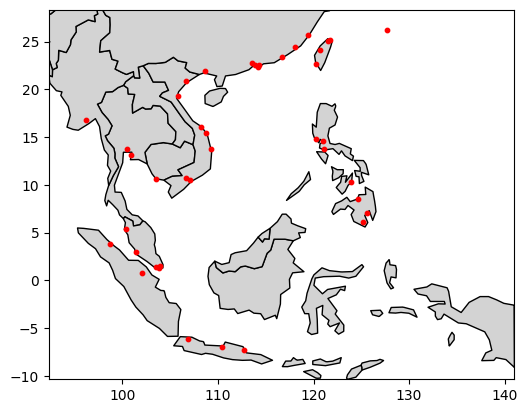

In [4]:
asia_pacific_countries = [
	#'China','Taiwan', 'Japan', 'South Korea',
	'Vietnam', 'Myanmar', 'Laos', 'Thailand', 'Cambodia',
	'Indonesia', 'Philippines', 'Malaysia', 'Singapore', 'Brunei', 'Timor-Leste',
	#'Pakistan', 'India', 'Bangladesh', 'Sri Lanka', 'Nepal','Maldives',
	#'Australia', 'Papua New Guinea', 'New Zealand', 'Solomon Islands',
	#'Vanuatu', 'Samoa', 'Tonga', 'Tuvalu', 'Nauru', 'Palau', 'Marshall Islands','Kiribati' #, 'Fiji'
]
assert portpool is not None
_, ax, portpool_selected = portpool.plot(asia_pacific_countries, plot_port_id = False)

In [5]:
# display port information
n_show = 2

for idx_port, port in enumerate(portpool_selected.tolist_port()):
	if idx_port > n_show - 1:
		break
	print(port, port.fit_vessel_ranks)
	print(port, port.berth_productivity)
	print(port, port.cost_portcall)
	print(port, port.get_producticity(vesselpool))
	print(port, port.get_portcall_costs(vesselpool))
	print('----')

CNFUG {3: 99999, 4: 99999, 5: 99999, 6: 99999, 7: 99999, 8: 99999, 9: 99999, 10: 8.0, 11: 12.0}
CNFUG {3: 26.46, 4: 31.46, 5: 27.82, 6: 30.38, 7: 40.31, 8: 10.67, 9: 34.64, 10: 80.72, 11: 71.94}
CNFUG {3: 8363.97, 4: 7819.0, 5: 11683.0, 6: 13271.0, 7: 16308.0, 8: 19549.0, 9: 24576.0, 10: 62287.0, 11: 53101.0}
CNFUG [0.0, 0.0, 26.46, 31.46, 27.82, 30.38, 40.31, 10.67, 34.64, 80.72, 71.94, 0.0, 0.0]
CNFUG [20000.0, 20000.0, 8363.97, 7819.0, 11683.0, 13271.0, 16308.0, 19549.0, 24576.0, 62287.0, 53101.0, 20000.0, 20000.0]
----
CNNSA {3: 99999, 4: 2.0, 5: 99999, 6: 99999, 7: 12.0, 8: 10.0, 9: 8.0}
CNNSA {3: 27.32, 4: 36.07, 5: 43.43, 6: 44.27, 7: 49.12, 8: 56.42, 9: 87.21}
CNNSA {3: 5161.4, 4: 1953.26, 5: 8467.9, 6: 8239.92, 7: 4300.39, 8: 4092.84, 9: 7235.78}
CNNSA [0.0, 0.0, 27.32, 36.07, 43.43, 44.27, 49.12, 56.42, 87.21, 0.0, 0.0, 0.0, 0.0]
CNNSA [20000.0, 20000.0, 5161.4, 1953.26, 8467.9, 8239.92, 4300.39, 4092.84, 7235.78, 20000.0, 20000.0, 20000.0, 20000.0]
----


In [6]:
print('Ports filtered by Max Draft')
print(0, len(portpool_selected.filter_by_max_draft(0)))
print(5, len(portpool_selected.filter_by_max_draft(5)))
print(10, len(portpool_selected.filter_by_max_draft(10)))
print(15, len(portpool_selected.filter_by_max_draft(15)))
print(20, len(portpool_selected.filter_by_max_draft(20)))
print(25, len(portpool_selected.filter_by_max_draft(25)))
print(30, len(portpool_selected.filter_by_max_draft(30)))

Ports filtered by Max Draft
0 41
5 41
10 33
15 15
20 7
25 7
30 6


In [7]:
print('Ports filtered by Transshipment Cost')
print(1000, len(portpool_selected.filtered_by_transship_cost(1000)))
print(500, len(portpool_selected.filtered_by_transship_cost(500)))
print(250, len(portpool_selected.filtered_by_transship_cost(250)))
print(125, len(portpool_selected.filtered_by_transship_cost(125)))
print(75, len(portpool_selected.filtered_by_transship_cost(75)))

Ports filtered by Transshipment Cost
1000 41
500 41
250 41
125 30
75 17


### Current Lines Data

In [8]:
current_lines, _ = cma.read_current_line_data(portpool_selected)

How many lines? 10
Example:
CP2CNC -- [CNSHK, HKHKG, CNNSA, PHMNL, PHBTG, PHDVO]


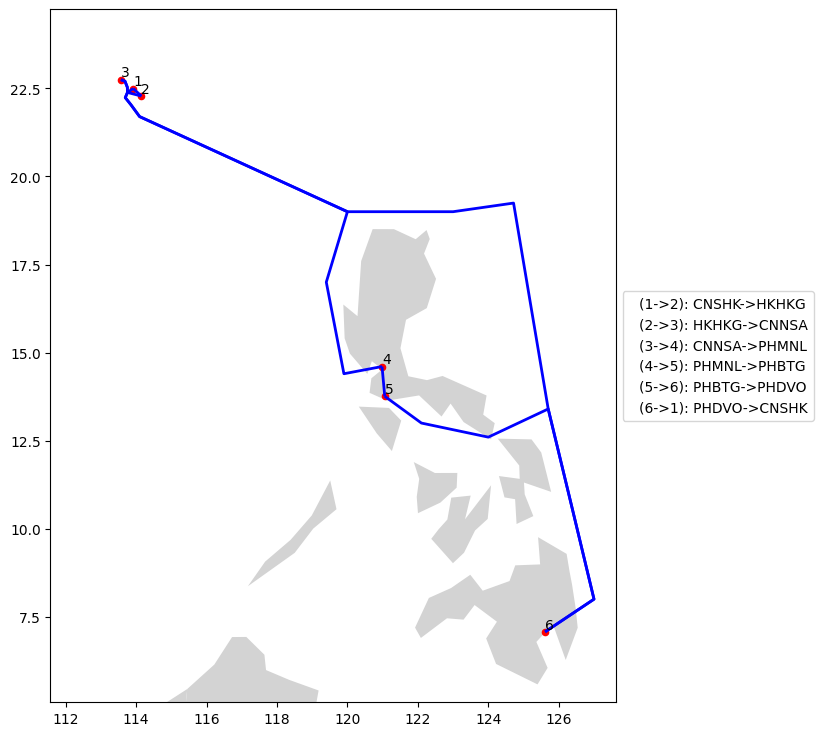

In [9]:
print('How many lines?', len(current_lines))
print('Example:')
line_0 = current_lines[0]
print(line_0)
line_0.plot(asia_pacific_countries)

### Service Graph

In [10]:
# distance data
dist_mat = cma.read_sailing_distance_data(portpool_selected)

# demand data
demands_dict, total_weekly_demand_mat = cma.read_demand_data(portpool_selected)
# this is not a dense matrix but a sparse matrix
(total_weekly_demand_mat > 0).sum()

np.int64(373)

In [11]:
# create a collection of ports
portgraph = cma.PortGraph(portpool_selected, dist_mat, total_weekly_demand_mat)
# create the current servicelines graph
servicegraph = cma.ServiceGraph(current_lines)

In [12]:
# Use other criterions to filter transship hubs
trans_ports_1 = portgraph.filter_by_max_draft(15)
trans_ports_2 = portgraph.filtered_by_transship_cost(100)
trans_ports = list(set(trans_ports_1) & set(trans_ports_2))
len(trans_ports)

8

In [13]:
# Use transshipment capacity
trans_ports = portgraph.filtered_by_transship_capacity()
len(trans_ports)

8

In [14]:
od_pairs_dict = servicegraph.get_all_paths(portgraph, trans_ports)
od_pairs = od_pairs_dict['od_pairs']
od_pairs_paths = od_pairs_dict['od_pairs_path']
od_pairs_demand = od_pairs_dict['od_pairs_demand']
unconnected = od_pairs_dict['unconnected']
unconnected_demand = od_pairs_dict['unconnected_demand']

num_all_paths = 0
for pair, paths in zip(od_pairs, od_pairs_paths):
	num_all_paths += len(paths)
# print(od_pairs_demand)
print(len(od_pairs))
print(num_all_paths)
print(len(unconnected))
print(sum(unconnected_demand), sum(od_pairs_demand))

127
434
246
9446.0 17971.0


In [15]:
week_predict_model, _ = cma.update_week_predictor(
	pd.DataFrame(), servicegraph.tolist_serviceLine(), portgraph, vesselpool)

In [16]:
week_levels= (1/2, 1, 2, 3, 4, 5, 6, 7, 8, 9)
n_od_pairs = -1
sol = servicegraph.fulfill_demands_2(
	od_pairs[:n_od_pairs],
	od_pairs_paths[:n_od_pairs],
	portgraph, vesselpool,
	week_predict_model)
sol['total cost']

np.float64(2512868.8884632215)

In [17]:
line_weeks = sol['weeks']
ship_vars = sol['ships']

print('Line Name', ' \t', 'distance', '\t', 'week', '\t', 'sailing-days', '\t', 'ships')
for line, week, days, line_ships in zip(current_lines, line_weeks, sol['line sailing days'], ship_vars):
	line_ships_val = [int(ship.value) for ship in line_ships]
	if not isinstance(days, float):
		days = days.value
	print(
		line.name(), ' \t',
		int(line.get_distance(portgraph)), '\t\t',
		week, '\t',
		round(days, 2),'\t\t',
		line_ships_val)

Line Name  	 distance 	 week 	 sailing-days 	 ships
CP2CNC  	 3929 		 2 	 12.47 		 [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
CP3CNC  	 2730 		 2 	 12.53 		 [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
HHX3CNC  	 1308 		 1 	 6.87 		 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
JSSCNC  	 2348 		 2 	 11.69 		 [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
LCXPCNC  	 1839 		 1 	 6.47 		 [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
RBHCNC  	 3556 		 2 	 12.35 		 [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
RMNCNC  	 2943 		 2 	 10.48 		 [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
SGSCNC  	 1554 		 1 	 6.18 		 [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
SPXCNC  	 4135 		 2 	 13.85 		 [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
TIXCNC  	 2495 		 2 	 14.0 		 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
